# Aula 3 - **Engenharia e Seleção de Features + Redução de Dimensionalidade**

- Engenharia de Features;
- Seleção de Features;
- Redução de Dimensionalidade.

## **1) 🛠️ Feature Engineering**

A engenharia de features é o processo de criar, transformar ou extrair novas variáveis (features) a partir dos dados brutos.

Ela é considerada uma das etapas mais importantes de Machine Learning, pois a qualidade das variáveis geralmente tem mais impacto no desempenho dos modelos do que o próprio algoritmo utilizado.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
df_titanic = pd.read_csv('/content/drive/MyDrive/Python para ML - 2026/Dados/Titanic-Dataset.csv')

In [5]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**1. Criação de variáveis derivadas**

- A partir de atributos existentes, podemos gerar informações adicionais.

- Exemplo: em um dataset de vendas, criar a coluna Valor_Total = Preço × Quantidade.

- Em dados de passageiros, calcular FamilySize = SibSp + Parch + 1.

In [6]:
df_titanic['FamilySize'] = df_titanic['SibSp'] + df_titanic['Parch'] + 1

In [7]:
df_titanic.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,1
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,1
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,5
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,3
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,2


**2. Transformações matemáticas**

- Aplicar logaritmos, raízes, padronização ou normalização para reduzir assimetria ou controlar a influência de outliers.

- Exemplo: usar log(Fare) na base Titanic para reduzir a dispersão dos valores de tarifa.

In [8]:
import numpy as np

In [9]:
df_titanic['Log_Fare'] = np.log(df_titanic['Fare'])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [10]:
df_titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Log_Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.904602,-inf
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,1.613459,NaN
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000,-inf
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.000000,2.068177
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000,2.670985
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,2.000000,3.433987
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000,6.238967


**3. Extração de informações de datas e textos**

- Datas podem ser decompostas em ano, mês, dia da semana, hora, feriado, etc.

- Textos podem ser transformados em variáveis numéricas via Bag of Words, TF-IDF ou embeddings.

- Exemplo 1: de uma coluna DataCompra, extrair Mês e Dia_da_Semana como variáveis categóricas.

- Exemplo 2: Extrair Mr, Mrs dos nomes dos passageiros.

In [11]:
#Criando uma variável de data
df = pd.DataFrame({
    'data': pd.date_range('2026-03-11', periods= 5, freq='D'),
    'valor': [10,20,15,30,25]
})

In [12]:
df['dia_semana'] = df['data'].dt.day_name()

In [13]:
df

,data,valor,dia_semana
0,2026-03-11,10,Wednesday
1,2026-03-12,20,Thursday
2,2026-03-13,15,Friday
3,2026-03-14,30,Saturday
4,2026-03-15,25,Sunday


In [14]:
nomes = []
for nome in df_titanic['Name']:
  nomes.append(nome.split()[1])

In [15]:
df_titanic['Pron_Trat'] = nomes

In [16]:
'''
from pandas.core.arrays import categorical
['o','gato','e','o','rato']
#Remoção de stopwords
1. ['gato','rato']
2. ['gato','gato']
3. ['rato','cão']
#Transformação pelo BoW
gato rato, cao
  1,   1 ,  0
  2,   0 ,  0
  0,   1 ,  1
'''

"\nfrom pandas.core.arrays import categorical\n['o','gato','e','o','rato']\n#Remoção de stopwords\n1. ['gato','rato']\n2. ['gato','gato']\n3. ['rato','cão']\n#Transformação pelo BoW\ngato rato, cao\n  1,   1 ,  0\n  2,   0 ,  0\n  0,   1 ,  1\n"

1. o gato e o rato
2. o gato e o gato
3. o rato e o cão

BoW

  gato, rato, cão
1. 1, 1, 0
2. 2, 0, 0
3. 0, 1, 1


In [17]:
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Log_Fare,Pron_Trat
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,1.981001,Mr.
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,4.266662,Mrs.
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,2.070022,Miss.
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,3.972177,Mrs.
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,2.085672,Mr.


## **2) 🎯 Seleção de Features**

Nem todas as variáveis contribuem igualmente para o modelo. Algumas podem ser redundantes ou até mesmo ruidosas.

A seleção de features ajuda a identificar quais variáveis realmente são relevantes para a previsão.

**1. Correlação entre variáveis**

- Analisar a correlação de Pearson/Spearman entre cada feature e a variável alvo.

- Variáveis altamente correlacionadas entre si podem ser redundantes e removidas.

![](https://observatorioobstetricobr.org/wp-content/uploads/2024/05/1.png)

**Correlação de pearson**

![](https://media.licdn.com/dms/image/v2/D4D12AQGgbmY_DPgwhg/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1701198267523?e=2147483647&v=beta&t=xAiFAzZzY-0QEF15v0GRLHWh3OovoUqWNiRdxJAViqc)

In [18]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  FamilySize   891 non-null    int64  
 13  Log_Fare     891 non-null    float64
 14  Pron_Trat    891 non-null    object 
dtypes: float64(3), int64(6), object(6)
memory usage: 104.5+ KB


In [19]:
df_titanic.drop(columns=['Name'],inplace=True)

In [20]:
colunas_numericas = df_titanic.select_dtypes('number').columns.to_list()
colunas_categoricas = df_titanic.select_dtypes('object').columns.to_list()

In [21]:
colunas_numericas

['PassengerId',
 'Survived',
 'Pclass',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'FamilySize',
 'Log_Fare']

In [22]:
colunas_categoricas

['Sex', 'Ticket', 'Cabin', 'Embarked', 'Pron_Trat']

In [23]:
df_titanic['Pron_Trat'].unique()

array(['Mr.', 'Mrs.', 'Miss.', 'Master.', 'Planke,', 'Don.', 'Rev.',
       'Billiard,', 'der', 'Walle,', 'Dr.', 'Pelsmaeker,', 'Mulder,', 'y',
       'Steen,', 'Carlo,', 'Mme.', 'Impe,', 'Ms.', 'Major.', 'Gordon,',
       'Messemaeker,', 'Mlle.', 'Col.', 'Capt.', 'Velde,', 'the',
       'Shawah,', 'Jonkheer.', 'Melkebeke,', 'Cruyssen,'], dtype=object)

In [24]:
trat = []
for pronome in df_titanic['Pron_Trat']:
  if pronome in ['Mr.', 'Mrs.', 'Miss.', 'Master.','Don.', 'Rev.','Dr.','Mme.', 'Ms.', 'Major.''Mlle.', 'Col.', 'Capt.','Jonkheer.']:
    trat.append(pronome)
  else:
    trat.append('Sem pronome')

In [25]:
df_titanic['Ticket'].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [26]:
df_titanic.drop(columns=['Ticket'],inplace=True)

In [27]:
df_titanic['Pron_Trat'] = trat

In [28]:
df_titanic['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [29]:
cabine = []
for cabin in df_titanic['Cabin']:
  if cabin is np.nan:
    cabine.append('S')
  else:
    cabine.append(cabin[0])

In [30]:
df_titanic['Cabin'] = cabine

In [31]:
df_titanic['Cabin'].unique()

array(['S', 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [32]:
df_titanic['Pron_Trat'].unique()

array(['Mr.', 'Mrs.', 'Miss.', 'Master.', 'Sem pronome', 'Don.', 'Rev.',
       'Dr.', 'Mme.', 'Ms.', 'Col.', 'Capt.', 'Jonkheer.'], dtype=object)

In [33]:
df_titanic['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [34]:
df_titanic.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,FamilySize,Log_Fare,Pron_Trat
0,1,0,3,male,22.0,1,0,7.2500,S,S,2,1.981001,Mr.
1,2,1,1,female,38.0,1,0,71.2833,C,C,2,4.266662,Mrs.
2,3,1,3,female,26.0,0,0,7.9250,S,S,1,2.070022,Miss.
3,4,1,1,female,35.0,1,0,53.1000,C,S,2,3.972177,Mrs.
4,5,0,3,male,35.0,0,0,8.0500,S,S,1,2.085672,Mr.


In [35]:
!pip install category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 6.0 MB/s eta 0:00:00


In [41]:
from category_encoders import OneHotEncoder

In [46]:
colunas_categoricas.remove('Ticket')

In [47]:
df_titanic

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,FamilySize,Log_Fare,Pron_Trat
0,1,0,3,male,22.0,1,0,7.2500,S,S,2,1.981001,Mr.
1,2,1,1,female,38.0,1,0,71.2833,C,C,2,4.266662,Mrs.
2,3,1,3,female,26.0,0,0,7.9250,S,S,1,2.070022,Miss.
3,4,1,1,female,35.0,1,0,53.1000,C,S,2,3.972177,Mrs.
4,5,0,3,male,35.0,0,0,8.0500,S,S,1,2.085672,Mr.
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0000,S,S,1,2.564949,Rev.
887,888,1,1,female,19.0,0,0,30.0000,B,S,1,3.401197,Miss.
888,889,0,3,female,NaN,1,2,23.4500,S,S,4,3.154870,Miss.
889,890,1,1,male,26.0,0,0,30.0000,C,C,1,3.401197,Mr.


In [48]:
onehot = OneHotEncoder(cols= colunas_categoricas, use_cat_names=True)

In [49]:
df_titanic_transformado = onehot.fit_transform(df_titanic)

In [50]:
df_titanic_transformado

,PassengerId,Survived,Pclass,Sex_male,Sex_female,Age,SibSp,Parch,Fare,Cabin_S,...,Pron_Trat_Master.,Pron_Trat_Sem pronome,Pron_Trat_Don.,Pron_Trat_Rev.,Pron_Trat_Dr.,Pron_Trat_Mme.,Pron_Trat_Ms.,Pron_Trat_Col.,Pron_Trat_Capt.,Pron_Trat_Jonkheer.
0,1,0,3,1,0,22.0,1,0,7.2500,1,...,0,0,0,0,0,0,0,0,0,0
1,2,1,1,0,1,38.0,1,0,71.2833,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1,3,0,1,26.0,0,0,7.9250,1,...,0,0,0,0,0,0,0,0,0,0
3,4,1,1,0,1,35.0,1,0,53.1000,0,...,0,0,0,0,0,0,0,0,0,0
4,5,0,3,1,0,35.0,0,0,8.0500,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,1,0,27.0,0,0,13.0000,1,...,0,0,0,1,0,0,0,0,0,0
887,888,1,1,0,1,19.0,0,0,30.0000,0,...,0,0,0,0,0,0,0,0,0,0
888,889,0,3,0,1,NaN,1,2,23.4500,1,...,0,0,0,0,0,0,0,0,0,0
889,890,1,1,1,0,26.0,0,0,30.0000,0,...,0,0,0,0,0,0,0,0,0,0


**2. Importância de variáveis**

- Algoritmos de Machine Learning, como Árvores de Decisão, Random Forest, XGBoost, fornecem métricas de importância das variáveis.

- Permite ranquear as features de acordo com sua contribuição para o modelo.



In [51]:
df_titanic_transformado['Age'] = df_titanic_transformado['Age'].fillna(df_titanic_transformado['Age'].mean())

In [52]:
df_titanic_transformado.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex_male,0
Sex_female,0
Age,0
SibSp,0
Parch,0
Fare,0
Cabin_S,0


In [53]:
df_titanic_transformado.drop(columns=['Embarked_nan','Pron_Trat_Sem pronome'],inplace=True)

In [54]:
df_titanic_transformado.corr()

,PassengerId,Survived,Pclass,Sex_male,Sex_female,Age,SibSp,Parch,Fare,Cabin_S,...,Pron_Trat_Miss.,Pron_Trat_Master.,Pron_Trat_Don.,Pron_Trat_Rev.,Pron_Trat_Dr.,Pron_Trat_Mme.,Pron_Trat_Ms.,Pron_Trat_Col.,Pron_Trat_Capt.,Pron_Trat_Jonkheer.
PassengerId,1.000000,-0.005007,-0.035144,0.042939,-0.042939,0.033207,-0.057527,-0.001652,0.012658,-0.019919,...,-0.073434,-0.026151,-0.054084,0.012698,0.034547,-0.009904,-0.000261,0.041584,0.039097,0.049131
Survived,-0.005007,1.000000,-0.338481,-0.543351,0.543351,-0.069809,-0.035322,0.081629,0.257307,-0.316912,...,0.329999,0.085221,-0.026456,-0.064988,0.008185,0.042470,0.042470,0.011329,-0.026456,-0.026456
Pclass,-0.035144,-0.338481,1.000000,0.131900,-0.131900,-0.331339,0.083081,0.018443,-0.549500,0.725541,...,-0.004180,0.082081,-0.052496,-0.030413,-0.108935,-0.052496,-0.012381,-0.074282,-0.052496,-0.052496
Sex_male,0.042939,-0.543351,0.131900,1.000000,-1.000000,0.084153,-0.114631,-0.245489,-0.182333,0.140391,...,-0.679688,0.159934,0.024728,0.060741,0.039034,-0.045439,-0.045439,0.034990,0.024728,0.024728
Sex_female,-0.042939,0.543351,-0.131900,-1.000000,1.000000,-0.084153,0.114631,0.245489,0.182333,-0.140391,...,0.679688,-0.159934,-0.024728,-0.060741,-0.039034,0.045439,0.045439,-0.034990,-0.024728,-0.024728
Age,0.033207,-0.069809,-0.331339,0.084153,-0.084153,1.000000,-0.232625,-0.179191,0.091566,-0.233123,...,-0.242067,-0.377265,0.026571,0.085335,0.072201,-0.014701,-0.004383,0.103299,0.103957,0.021412
SibSp,-0.057527,-0.035322,0.083081,-0.114631,0.114631,-0.232625,1.000000,0.414838,0.159651,0.040460,...,0.084842,0.349559,-0.015907,-0.026622,0.003910,-0.015907,-0.015907,-0.022508,0.014507,-0.015907
Parch,-0.001652,0.081629,0.018443,-0.245489,0.245489,-0.179191,0.414838,1.000000,0.216225,-0.036987,...,0.103250,0.267344,-0.015878,-0.021967,-0.042150,-0.015878,-0.015878,-0.022467,0.025731,-0.015878
Fare,0.012658,0.257307,-0.549500,-0.182333,0.182333,0.091566,0.159651,0.216225,1.000000,-0.482075,...,0.121297,0.010908,-0.003026,-0.023031,0.030395,0.025037,-0.012961,-0.001126,0.026184,-0.021735
Cabin_S,-0.019919,-0.316912,0.725541,0.140391,-0.140391,-0.233123,0.040460,-0.036987,-0.482075,1.000000,...,-0.040113,0.027841,0.018266,0.044868,-0.042277,-0.061513,0.018266,-0.030598,-0.061513,0.018266


In [55]:
df_titanic_transformado.drop(columns=['Log_Fare'],inplace=True)

![](https://kajabi-storefronts-production.kajabi-cdn.com/kajabi-storefronts-production/file-uploads/blogs/2147508623/images/f5373fb-7eae-621-7bba-8aa553e104_Feature_Importance-1.jpg)

In [56]:
X = df_titanic_transformado.drop(columns=['Survived'])
y = df_titanic_transformado['Survived']

In [57]:
from sklearn.ensemble import RandomForestClassifier

In [58]:
#Instanciar um modelo de Random Forest
modelo = RandomForestClassifier(random_state=42, max_depth= 5)

In [59]:
#Treinar o modelo

In [60]:
modelo.fit(X,y)

RandomForestClassifier(max_depth=5, random_state=42)

In [61]:
modelo.feature_importances_

array([2.61028559e-02, 6.92149054e-02, 1.73371362e-01, 1.62434884e-01,
       3.93174744e-02, 2.50697462e-02, 1.52792496e-02, 8.53540810e-02,
       4.61898743e-02, 2.92285546e-03, 9.98895600e-03, 1.78508478e-03,
       5.17932744e-03, 1.58857872e-03, 5.61028230e-03, 9.63799137e-04,
       2.02550409e-04, 9.18982397e-03, 1.02701944e-02, 3.53291220e-03,
       5.02391026e-02, 1.45691072e-01, 4.32624360e-02, 4.64677294e-02,
       1.65616863e-02, 1.31874858e-04, 1.87674232e-03, 9.48230985e-04,
       5.96918258e-06, 5.73622159e-05, 7.22990122e-04, 4.66006754e-04,
       0.00000000e+00])

In [62]:
importancia = pd.DataFrame({
    'Variável':X.columns,
    'Importância': modelo.feature_importances_
}).sort_values(by='Importância', ascending = False)

In [63]:
importancia

,Variável,Importância
2,Sex_male,0.173371
3,Sex_female,0.162435
21,Pron_Trat_Mr.,0.145691
7,Fare,0.085354
1,Pclass,0.069215
20,FamilySize,0.050239
23,Pron_Trat_Miss.,0.046468
8,Cabin_S,0.046190
22,Pron_Trat_Mrs.,0.043262
4,Age,0.039317


**SHAP**

O SHAP é uma técnica de interpretação de modelos de Machine Learning baseada em valores de Shapley, um conceito vindo da Teoria dos Jogos.

A ideia é atribuir a cada variável (feature) uma contribuição justa para a previsão final do modelo.

Ou seja, o SHAP mostra quanto cada variável aumentou ou diminuiu a previsão em comparação com uma média de referência.

![](https://www.researchgate.net/publication/343660536/figure/fig4/AS:924628193140736@1597459948038/a-Feature-importance-evaluated-using-the-mean-SHAP-values-in-the-LR-model-using-all.ppm)

## **3) 🔻 Redução de Dimensionalidade**

Quando temos muitas variáveis, o espaço de busca dos algoritmos cresce exponencialmente, levando ao fenômeno conhecido como maldição da dimensionalidade.

A redução de dimensionalidade busca representar os dados em um número menor de dimensões, mantendo ao máximo a informação relevante.

Para avaliarmos um exemplo de utilização da técnica, vamos aplicá-la a um [conjunto de dados de uma pesquisa de Marketing](https://www.kaggle.com/datasets/mahdinavaei/customermarketing).

In [64]:
df_customer = pd.read_csv("/content/drive/MyDrive/Python para ML - 2026/Dados/Customer marketing.csv",sep = "\t")

In [66]:
df_customer.head()

,ID_,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [67]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID_                  2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [68]:
df_customer['Age'] = 2026 - df_customer['Year_Birth']

In [69]:
df_customer['Age']

,Age
0,69
1,72
2,61
3,42
4,45
...,...
2235,59
2236,80
2237,45
2238,70


In [70]:
df_customer['Age'].describe()

,Age
count,2240.000000
mean,57.194196
std,11.984069
min,30.000000
25%,49.000000
50%,56.000000
75%,67.000000
max,133.000000


{'whiskers': [<matplotlib.lines.Line2D at 0x7bfa052ab6e0>,
 'caps': [<matplotlib.lines.Line2D at 0x7bfa052a4830>,
 'boxes': [<matplotlib.lines.Line2D at 0x7bfa052ab380>],
 'medians': [<matplotlib.lines.Line2D at 0x7bfa052a4f80>],
 'fliers': [<matplotlib.lines.Line2D at 0x7bfa052a5280>],
 'means': []}

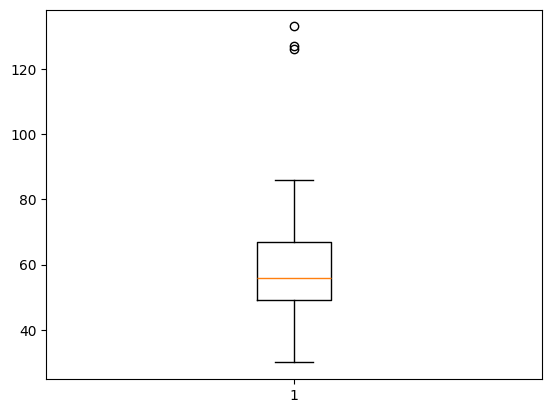

In [71]:
plt.boxplot(df_customer['Age'])

Temos 2 variáveis altamente correlacionadas

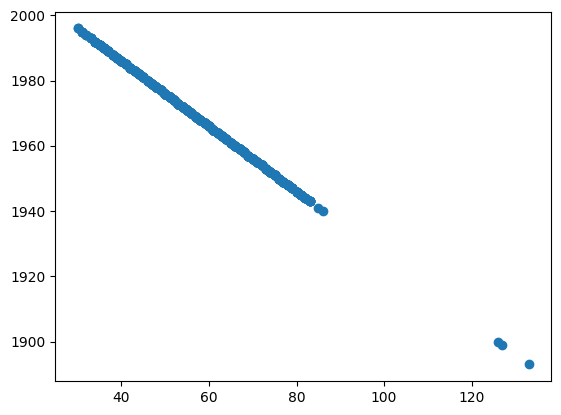

In [72]:
plt.scatter(df_customer['Age'],df_customer['Year_Birth'])

**1. PCA (*Principal Component Analysis*)**



A análise de componentes principais (PCA; *principal components analysis*) tem por objetivo obter uma projeção dos dados nas direções em que as **componentes principais** tenham máxima variância estatística.


Isso significa que, após a projeção, passamos de um espaço original para um espaço de dimensões reduzidas, em que, inevitavelmente, perdemos um pouco de informação (pois estamos "descartando dimensões").


No entanto, ao manter as projeções que conservam a maior parte da variância nos dados, estamos, concomitantemente, tentando reter aquilo do dado que é mais informativo sobre eles!

Para saber em mais detalhes sobre o método:
- [Descrição de PCA na Wikipedia](https://pt.wikipedia.org/wiki/An%C3%A1lise_de_componentes_principais)
- [PCA with Python](https://www.geeksforgeeks.org/principal-component-analysis-with-python/)
- [PCA for dummies](https://programmathically.com/principal-components-analysis-explained-for-dummies/)
- [A step-by-step explanation of PCA](https://builtin.com/data-science/step-step-explanation-principal-component-analysis)

![](https://lh6.googleusercontent.com/proxy/5FoHrYaHli1iqNXZunq4wg9GrHhZJFfUlRYrBLpxOXLd1R7b9a8Hkk_uukWQbLTWlvmnq07l6yypWJXBZXDbdfbq5uOrc7e32I4AdrCezl4)

Vamos ver o método na prática?

Vamos reduzir a dimensionalidade dos dados.

In [73]:
#Separando X e y
X = df_customer.drop(columns=['Income'])
y = df_customer['Income']

In [74]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [75]:
#Instanciando o meu padronizador
scaler = StandardScaler()

In [77]:
X = df_customer.drop(columns=['Income']).select_dtypes('number') #Escolhendo apenas as variáveis numéricas

In [79]:
X

,ID_,Year_Birth,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,0,0,58,635,88,546,172,88,...,0,0,0,0,0,0,3,11,1,69
1,2174,1954,1,1,38,11,1,6,2,1,...,0,0,0,0,0,0,3,11,0,72
2,4141,1965,0,0,26,426,49,127,111,21,...,0,0,0,0,0,0,3,11,0,61
3,6182,1984,1,0,26,11,4,20,10,3,...,0,0,0,0,0,0,3,11,0,42
4,5324,1981,1,0,94,173,43,118,46,27,...,0,0,0,0,0,0,3,11,0,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,0,1,46,709,43,182,42,118,...,0,0,0,0,0,0,3,11,0,59
2236,4001,1946,2,1,56,406,0,30,0,0,...,0,0,0,1,0,0,3,11,0,80
2237,7270,1981,0,0,91,908,48,217,32,12,...,0,1,0,0,0,0,3,11,0,45
2238,8235,1956,0,1,8,428,30,214,80,30,...,0,0,0,0,0,0,3,11,0,70


In [82]:
X.isnull().sum()

,0
ID_,0
Year_Birth,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0
MntFishProducts,0
MntSweetProducts,0


In [78]:
#Padronizar os dados
X_scaled = scaler.fit_transform(X)

In [80]:
#Instanciar o PCA

In [83]:
pca = PCA(n_components=4)

In [87]:
#Rodar o meu PCA
pca_data = pca.fit_transform(X_scaled)

[PCA no sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

In [88]:
pca_data

array([[ 3.95056786, -0.35906808, -0.36077784,  0.6852927 ],
       [-2.30466332, -1.44277827, -0.17168323, -1.48451929],
       [ 1.48141077, -0.2506631 , -1.02737837,  0.0491449 ],
       ...,
       [ 1.39399504,  0.92729557,  0.95984871, -0.05528106],
       [ 1.6910355 , -1.85412904, -0.93003408, -0.22810072],
       [-1.66384304, -1.48540826,  1.12262266, -0.61199944]])

In [89]:
#Criando um DataFrame com os resultados
df_pca_result = pd.DataFrame(
    data = pca_data,
    columns = ['PC1','PC2','PC3','PC4']
)

In [90]:
df_pca_result.head()

,PC1,PC2,PC3,PC4
0,3.950568,-0.359068,-0.360778,0.685293
1,-2.304663,-1.442778,-0.171683,-1.484519
2,1.481411,-0.250663,-1.027378,0.049145
3,-2.409628,1.928342,-0.151663,0.140106
4,-0.629671,1.104205,-0.613998,1.410964


Cada componente pega as informações das variáveis para explicar a variabilidade dos dados.

In [91]:
#Variância de cada componente
print(f'Variância de cada componente: {pca.explained_variance_ratio_}')

Variância de cada componente: [0.25120419 0.10346368 0.07901921 0.06618779]


In [92]:
#Variância total acumulada
print(f'Total de Variância acumulada: {pca.explained_variance_ratio_.sum() * 100:.2f}')

Total de Variância acumulada: 49.99


O que o código acima fez:
- quando usamos o **.fit** em PCA, estamos encontrando uma **matriz de projeção** que leva os dados do espaço original para o espaço de componentes principais. No nosso caso, passamos de um espaço de **36 dimensões para apenas 4!**;
- quando utilizamos o **.transform**, aplicamos a projeção calculada no fit aos dados, levando-os ao espaço de componentes principais;
- vale notar que, ao fazermos isso, **perdemos um pouco de explicabilidade**. Nossas componentes principais são **combinações lineares das features originais!**

E se eu quiser saber a quantidade para obter 95% da variabilidade?

In [93]:
pca_95 = PCA(n_components=0.95) #O parâmetro aceita um float de 0 a 1

In [94]:
#Rodar o meu PCA
pca_data_95 = pca_95.fit_transform(X_scaled)

In [95]:
print(f'Número de componentes necessários para 95% de variância é: {pca_95.n_components_}')

Número de componentes necessários para 95% de variância é: 19


Em suma:

- com a PCA, buscamos projeções ortogonais (independentes) de componentes principais, com o objetivo de reduzir a dimensionalidade do problema sendo tratado, ao mesmo tempo em que buscamos conservar o máximo de informação possível;
- o número de componentes principais, a princípio, pode ser definido arbitrariamente. Entretanto, podemos computar métricas que nos indiquem "quanto de informação retemos", do dataset original, a fim de auxiliar nessa escolha;
- cada componente principal será uma **combinação linear** das features originais, mas podemos utilizá-la normalmente como qualquer outro tipo de atributo (mas é importante ter essa consideração em mente, pois afeta a explicabilidade do modelo!).

Para mais detalhes sobre esse parâmetro, vocês podem consultar, por exemplo, [esta explicação](https://vitalflux.com/pca-explained-variance-concept-python-example/).

**Observação importante:**

Com a análise ilustrativa de PCA, objetivamos obter uma intuição acerca da interpretação do método! Note que não consideramos diversas boas práticas que deveríamos ter adotado, como limpeza do conjunto de dados, tratamento de possíveis valores nulos etc. Poderíamos, inclusive, ter criado novas features, por exemplo, para denotar o consumo total, ou similares, caso julgássemos cabível.

**2. t-SNE (*t-Distributed Stochastic Neighbor Embedding*)**

É um método estatístico para visualizar dados de alta dimensão, reduzindo-os a espaços de dimensões inferiores, normalmente duas ou três dimensões.

Isso facilita a visualização e a interpretação dos dados, especialmente ao lidar com conjuntos de dados complexos, como os de aprendizado de máquina e ciência de dados.

**Finalidade:**

O PCA funciona melhor em dados lineares, enquanto o t-SNE não tem essa restrição. Se os dados são lineares ou não lineares, o t-SNE tem um bom desempenho. Abaixo está uma visualização do conjunto de dados MNIST usando as técnicas PCA e t-SNE. Como fica evidente no diagrama, o t-SNE exibe particionamento superior dos dígitos em comparação com o PCA. Essa melhoria pode ser atribuída à não linearidade dos dados MNIST, que o t-SNE captura efetivamente enquanto o PCA luta.


![](https://miro.medium.com/v2/resize:fit:1100/format:webp/0*vz4K-fqiy19u_W-9)

**Ideia central:**

A ideia central por trás do t-SNE é mapear pontos de dados de alta dimensão para um espaço de dimensão inferior, normalmente duas ou três dimensões, de uma forma que preserve as relações locais entre os pontos.

**Como?** Medindo a semelhança entre os pontos de dados no espaço de alta dimensão e representando essa semelhança como probabilidades.

In [96]:
from sklearn.manifold import TSNE

In [97]:
#Instanciando o t-SNE para 2 dimensões
tsne = TSNE(n_components=2, perplexity=30, random_state=42)

In [98]:
#Aplicando o fit_transform
tsne_data = tsne.fit_transform(X_scaled)

In [99]:
#Criar um DF com os resultados para plotagem
df_tsne = pd.DataFrame(data = tsne_data, columns=['Dim_1','Dim_2'])

In [101]:
df_tsne.head()

,Dim_1,Dim_2
0,29.477825,30.302759
1,-17.116978,-50.582455
2,18.048445,11.133116
3,-44.020996,18.449833
4,-25.005436,16.911688


Visualizar os clusters:

Response significa se o cliente aceitou ou não a propaganda

In [103]:
df_customer['Response']

,Response
0,1
1,0
2,0
3,0
4,0
...,...
2235,0
2236,0
2237,0
2238,0


In [107]:
df_customer['Response'].value_counts()

,count
Response,
0,1906
1,334


<Axes: xlabel='Dim_1', ylabel='Dim_2'>

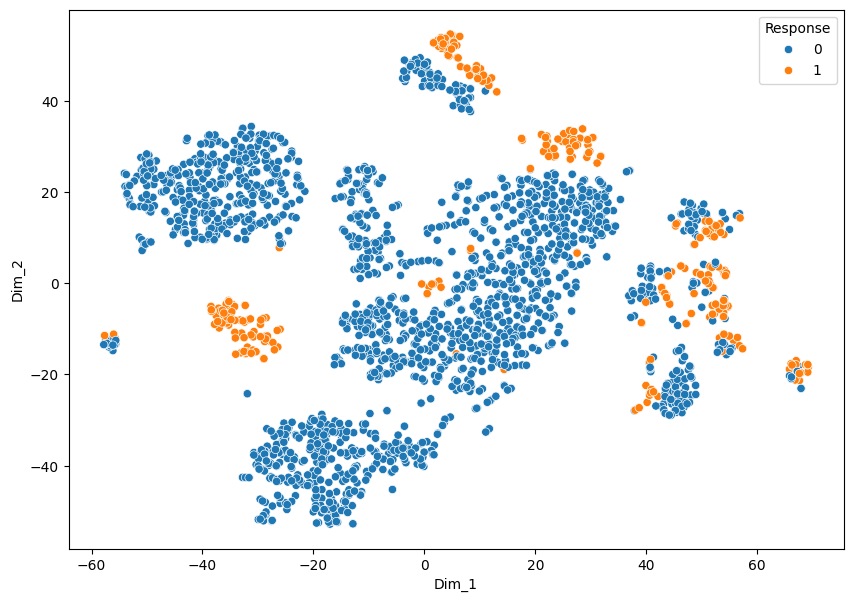

In [106]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x = 'Dim_1',y='Dim_2', data=df_tsne,
    hue = df_customer['Response'], #Colorir de acordo com a resposta da campanha
)